<a href="https://colab.research.google.com/github/njwbilll/Tugas-5_Grokking-Deep-Learning-MANNING_Najwa-Bilqis-Al-Khalidah/blob/main/04_How_Do_Neural_Networks_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 4: How Do Neural Networks Learn?

## Referensi

Grokking Deep Learning - Andrew W. Trask

---

## Learning Objectives

Pada chapter ini kita akan mempelajari:

1. Konsep learning pada neural network.
2. Error dan loss.
3. Perbedaan prediksi dan target.
4. Gradient Descent.
5. Mengubah weight secara otomatis.
6. Iterative learning process.
7. Training sederhana menggunakan Python.

---

## Ringkasan Chapter

Pada chapter sebelumnya kita membuat prediksi menggunakan weight yang ditentukan secara manual.

Pertanyaan pentingnya adalah:

Bagaimana neural network menemukan weight yang baik secara otomatis?

Chapter ini menjawab pertanyaan tersebut dengan memperkenalkan konsep error, gradient descent, dan update weight.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("Chapter 4 Loaded")


Chapter 4 Loaded



# 1. Apa Artinya Belajar?

Pada neural network, belajar berarti memperbaiki weight sehingga prediksi menjadi semakin dekat dengan target yang diinginkan.

Proses ini dilakukan secara bertahap melalui banyak iterasi.



# 2. Prediction dan Target

Prediction adalah hasil yang diberikan model.

Target adalah jawaban yang sebenarnya.

Tujuan training adalah membuat prediction sedekat mungkin dengan target.


In [2]:

prediction = 0.8
target = 1.0

print("Prediction:", prediction)
print("Target:", target)


Prediction: 0.8
Target: 1.0



# 3. Error

Error menunjukkan seberapa jauh prediksi dari target.

Formula sederhana:

error = target - prediction


In [3]:

prediction = 0.8
target = 1.0

error = target - prediction

print("Error:", error)


Error: 0.19999999999999996



# 4. Squared Error

Dalam machine learning sering digunakan squared error.

Formula:

error = (target - prediction)^2

Keuntungan:

* Selalu positif
* Error besar mendapat penalti lebih besar


In [4]:

prediction = 0.8
target = 1.0

squared_error = (target - prediction) ** 2

print(squared_error)


0.03999999999999998



# 5. Hubungan Weight dan Error

Nilai weight mempengaruhi prediksi.

Prediksi mempengaruhi error.

Karena itu kita dapat memperbaiki weight untuk mengurangi error.


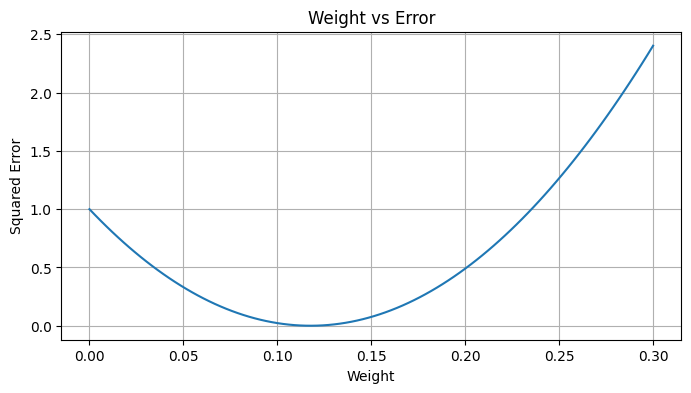

In [5]:

input_value = 8.5

weights = np.linspace(0,0.3,100)

errors = []

for w in weights:
    prediction = input_value * w
    error = (1 - prediction) ** 2
    errors.append(error)

plt.figure(figsize=(8,4))
plt.plot(weights, errors)
plt.title("Weight vs Error")
plt.xlabel("Weight")
plt.ylabel("Squared Error")
plt.grid(True)
plt.show()



# 6. Mencari Weight Terbaik

Weight terbaik adalah weight yang menghasilkan error terkecil.


In [6]:

best_weight = weights[np.argmin(errors)]

print("Best Weight:", round(best_weight,4))


Best Weight: 0.1182



# 7. Intuisi Gradient Descent

Bayangkan seseorang berada di puncak gunung dan ingin mencapai titik terendah.

Ia akan bergerak sedikit demi sedikit ke arah penurunan terbesar.

Ide yang sama digunakan dalam gradient descent.



# 8. Gradient

Gradient menunjukkan arah perubahan error terhadap weight.

Jika gradient positif, weight perlu dikurangi.

Jika gradient negatif, weight perlu ditambah.


In [7]:

weight = 0.1
input_value = 8.5
target = 1

prediction = input_value * weight

error = prediction - target

gradient = error * input_value

print("Gradient:", gradient)


Gradient: -1.2749999999999992



# 9. Learning Rate

Learning Rate menentukan seberapa besar langkah yang diambil saat memperbarui weight.

Terlalu kecil:

Training lambat.

Terlalu besar:

Training tidak stabil.


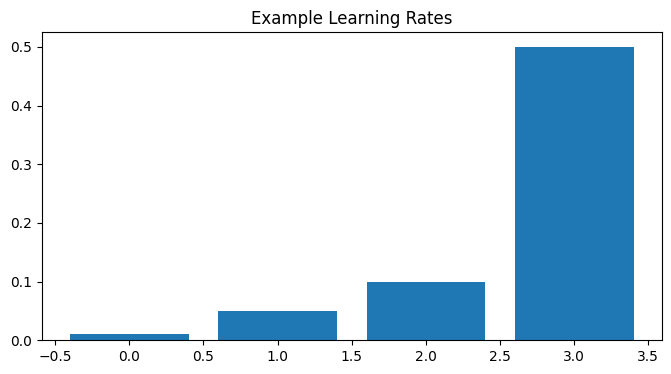

In [8]:

learning_rates = [0.01, 0.05, 0.1, 0.5]

plt.figure(figsize=(8,4))
plt.bar(range(len(learning_rates)), learning_rates)
plt.title("Example Learning Rates")
plt.show()



# 10. Weight Update

Formula sederhana:

new_weight = weight - learning_rate × gradient


In [9]:

weight = 0.1
learning_rate = 0.01

prediction = input_value * weight
error = prediction - target

gradient = error * input_value

new_weight = weight - learning_rate * gradient

print("Old Weight:", weight)
print("New Weight:", round(new_weight,4))


Old Weight: 0.1
New Weight: 0.1128



# 11. Satu Iterasi Training

Mari lihat satu langkah training lengkap.


In [10]:

weight = 0.1
input_value = 8.5
target = 1

prediction = input_value * weight
error = prediction - target
gradient = error * input_value

weight -= 0.01 * gradient

print(weight)


0.11275



# 12. Banyak Iterasi Training

Neural network biasanya dilatih selama banyak iterasi.


In [11]:

weight = 0.1
learning_rate = 0.01

history = []

for iteration in range(30):

    prediction = input_value * weight
    error = (target - prediction) ** 2

    history.append(error)

    gradient = (prediction - target) * input_value

    weight -= learning_rate * gradient

print("Final Weight:", round(weight,4))


Final Weight: 0.1176



# 13. Visualisasi Learning Process


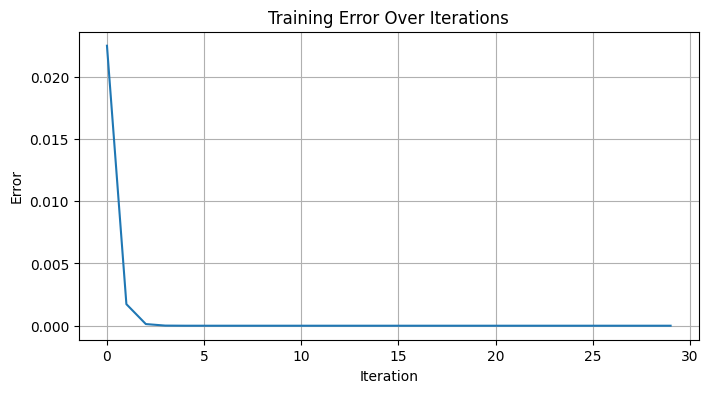

In [12]:

plt.figure(figsize=(8,4))
plt.plot(history)
plt.title("Training Error Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.grid(True)
plt.show()



# 14. Mengapa Error Menurun?

Setiap iterasi menggunakan informasi dari gradient untuk memperbaiki weight.

Akibatnya prediksi semakin dekat ke target.



# 15. Efek Learning Rate yang Berbeda


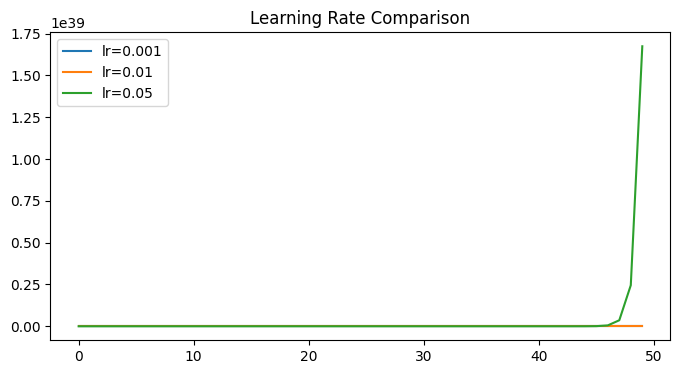

In [13]:

rates = [0.001,0.01,0.05]

plt.figure(figsize=(8,4))

for lr in rates:

    weight = 0.1
    losses = []

    for _ in range(50):

        pred = input_value * weight
        loss = (target - pred) ** 2

        losses.append(loss)

        grad = (pred - target) * input_value
        weight -= lr * grad

    plt.plot(losses,label=f"lr={lr}")

plt.legend()
plt.title("Learning Rate Comparison")
plt.show()



# 16. Kelebihan Gradient Descent

* Sederhana
* Efektif
* Digunakan hampir di semua deep learning modern
* Dapat diterapkan pada model besar



# 17. Keterbatasan

* Dapat terjebak local minimum
* Sensitif terhadap learning rate
* Membutuhkan banyak iterasi



# 18. Aplikasi Dunia Nyata

Gradient descent digunakan pada:

* Computer Vision
* NLP
* Recommendation System
* Time Series Forecasting
* Generative AI


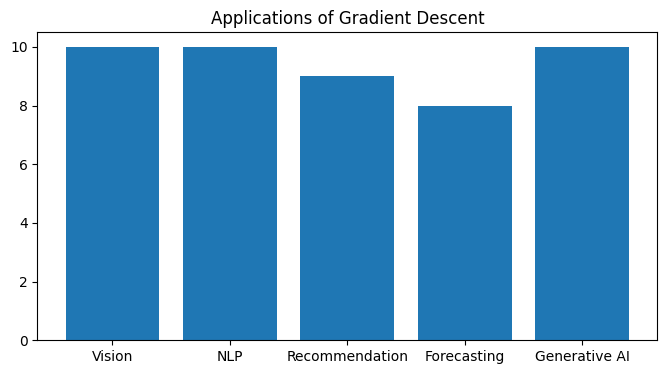

In [14]:

applications = ["Vision","NLP","Recommendation","Forecasting","Generative AI"]
scores = [10,10,9,8,10]

plt.figure(figsize=(8,4))
plt.bar(applications,scores)
plt.title("Applications of Gradient Descent")
plt.show()



# 19. Key Takeaways

1. Neural network belajar dengan memperbaiki weight.
2. Error mengukur kualitas prediksi.
3. Gradient menunjukkan arah perbaikan.
4. Learning rate menentukan ukuran langkah.
5. Gradient descent adalah fondasi training neural network.



# 20. Chapter Summary

Pada chapter ini kita mempelajari:

* Error
* Squared Error
* Gradient
* Learning Rate
* Weight Update
* Gradient Descent
* Iterative Learning

Konsep konsep ini menjadi fondasi utama bagi proses training neural network pada chapter chapter berikutnya.
